Name: Venkata Sri Sai Pavani Lanka
Github username: lanka1908
USC ID: 4885549248

a) Download Data

Package Imports

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

Get the Vertebral Column Data Set

In [3]:
column_name = ['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 
           'pelvic_radius', 'grade_of_spondylolisthesis', 'class']
df = pd.read_csv('../data/vertebral_column_data/column_2C.dat', names = column_name, sep=r"\s+")

In [4]:
df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,grade_of_spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,AB
1,39.06,10.06,25.02,29.00,114.41,4.56,AB
2,68.83,22.22,50.09,46.61,105.99,-3.53,AB
3,69.30,24.65,44.31,44.64,101.87,11.21,AB
4,49.71,9.65,28.32,40.06,108.17,7.92,AB


b) Pre-Processing and Exploratory Data Analysis

i) Making a scatter plot of the independent variables 

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
independent_variables = ['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_radius', 'grade_of_spondylolisthesis']
df['class'] = df['class'].map({'NO': 0, 'AB': 1})

Text(0.5, 1, 'Scatterplot of Independent variables')

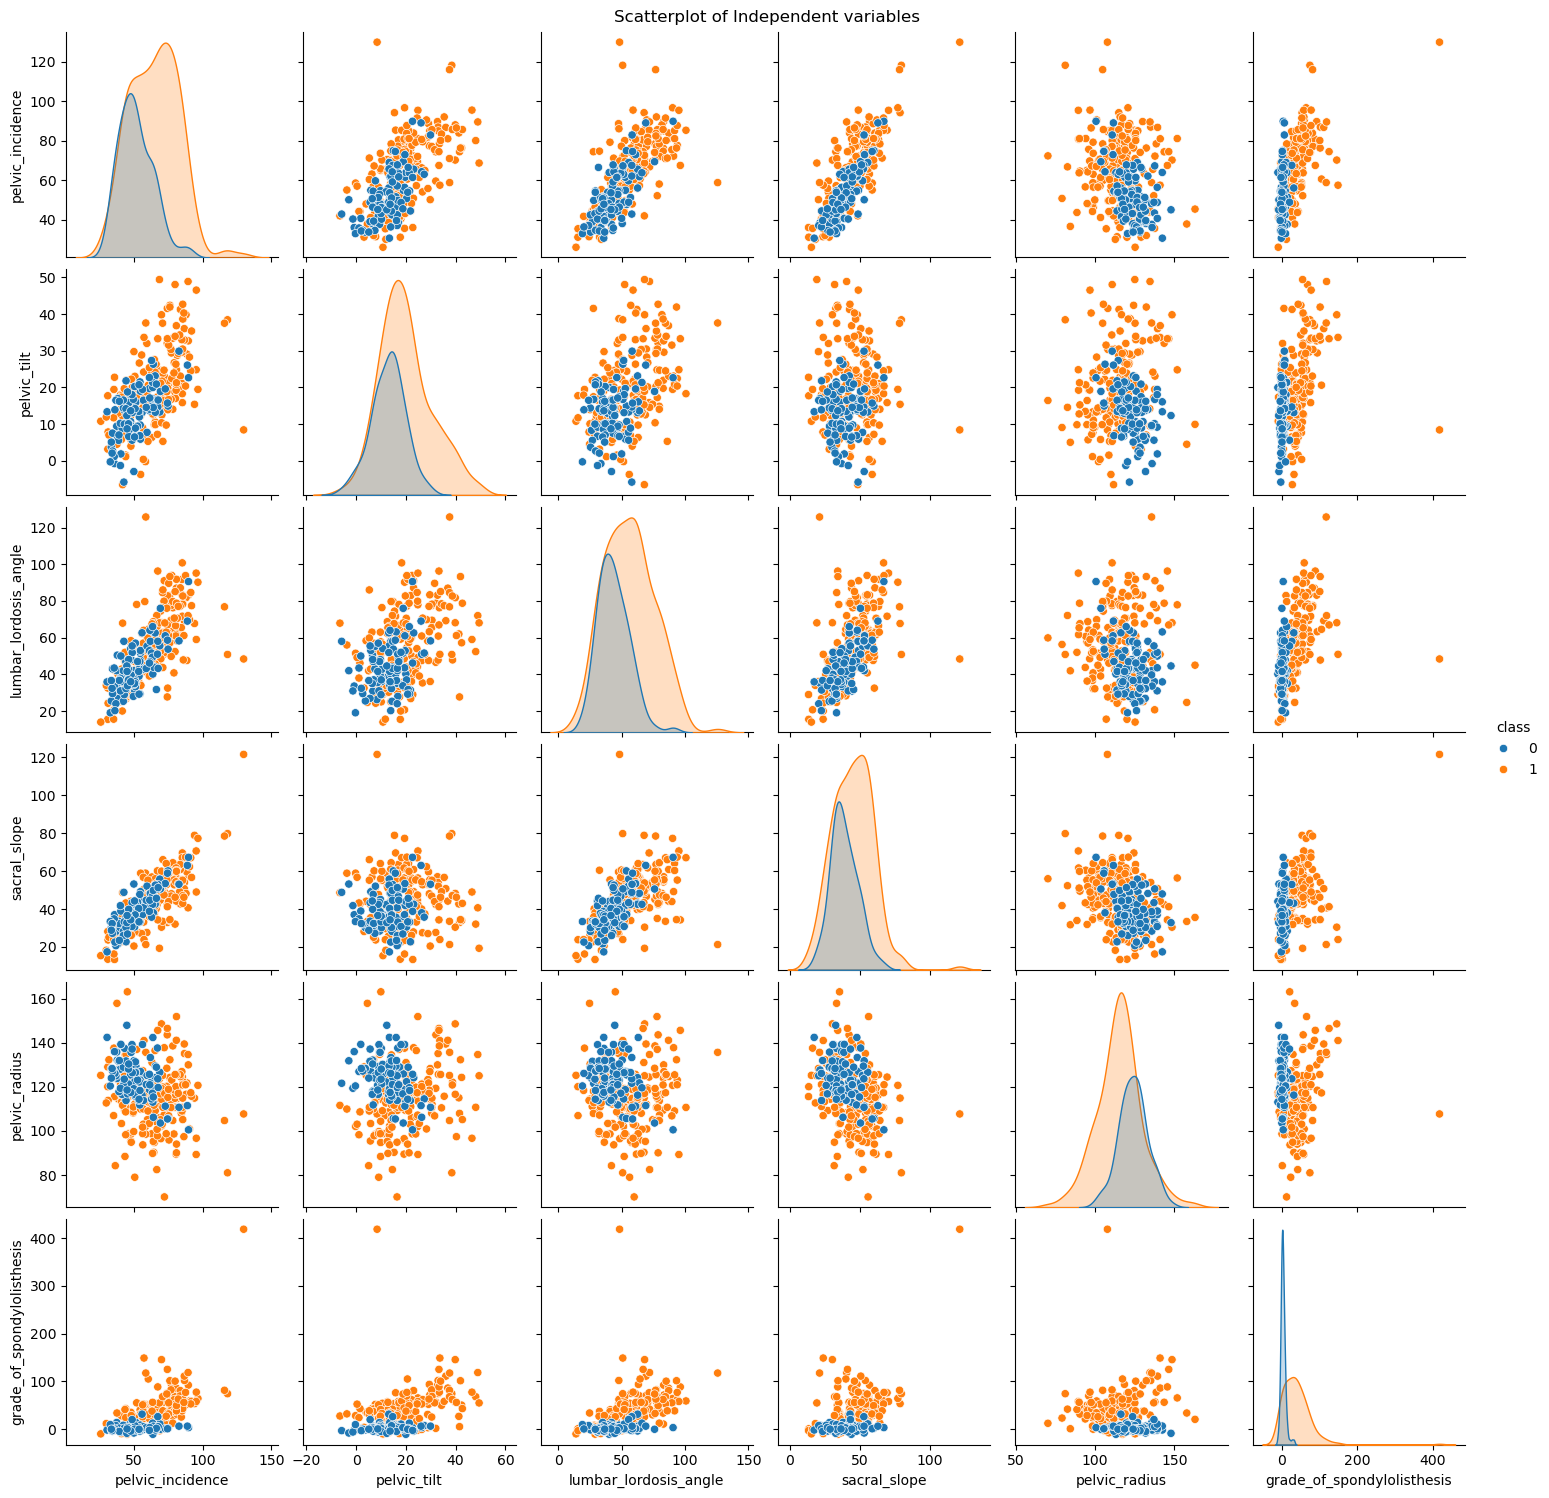

In [8]:
sns.pairplot(data=df, hue="class")
plt.suptitle('Scatterplot of Independent variables', y=1)

ii) To make boxplots for each of the independent variables

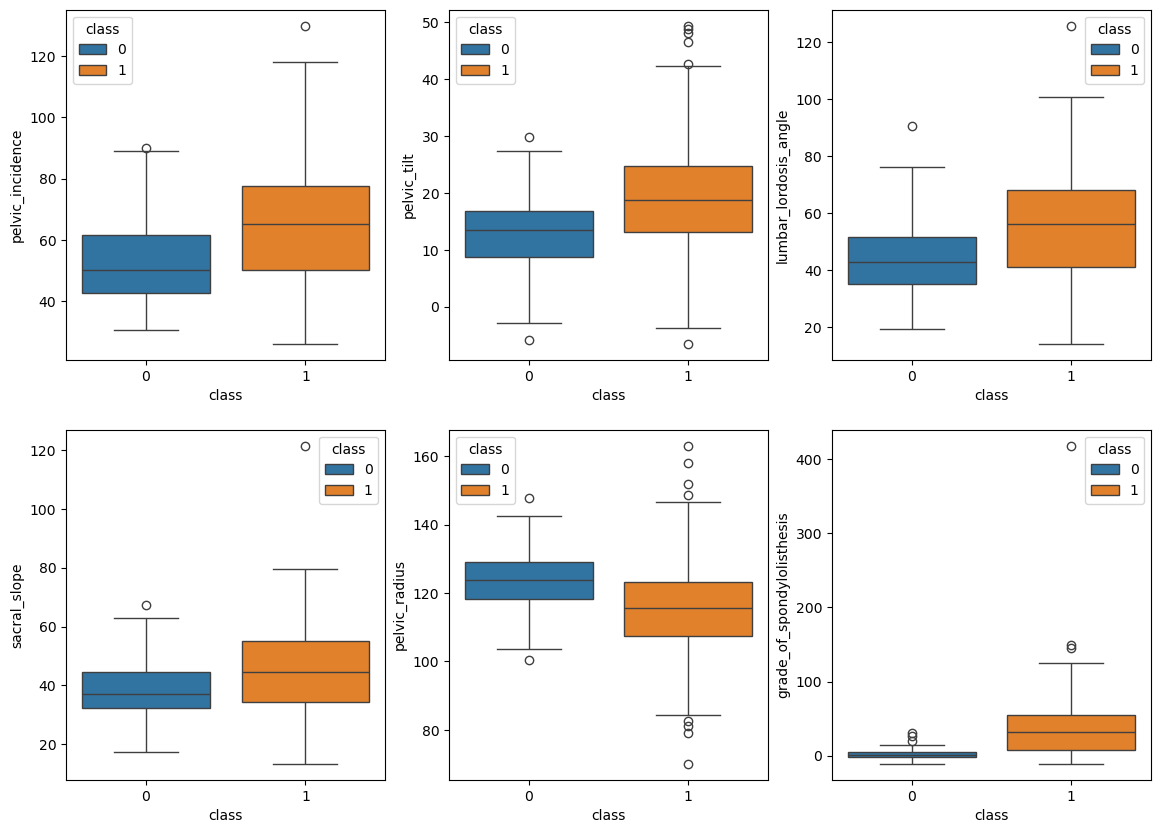

In [10]:
plt.figure(figsize=(14,10))
index = 1
for i in range(len(independent_variables)):
    plt.subplot(2,3,index)
    sns.boxplot(data=df, x = 'class', y = independent_variables[i], hue='class')
    index += 1

iii)  Selecting the first 70 rows of Class 0 and the first 140 rows of Class 1 as the training set and the rest of the data as the test set.
Split the dataset

In [12]:
class_0 = df[df['class'] == 0]
class_1 = df[df['class'] == 1]

In [13]:
training_class0 = class_0.iloc[:70] 
training_class1 = class_1.iloc[:140] 

train_set = pd.concat([training_class0, training_class1])

print(f"Training set: {train_set.shape}")

Training set: (210, 7)


In [14]:
testing_class0 = class_0.iloc[70:] 
testing_class1 = class_1.iloc[140:] 

test_set = pd.concat([testing_class0, testing_class1])

print(f"Testing set: {test_set.shape}")

Testing set: (100, 7)


c) Classification

i) Write code for k-nearest neighbors with Euclidean metric

In [16]:
X_train = train_set.iloc[:, :-1]
y_train = train_set['class']
X_test = test_set.iloc[:, :-1]
y_test = test_set['class']

In [17]:
k = 4
knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=4)

ii) Plot train and test errors in terms of k for k in {208,205,...,7,4,1} 
Test Data

In [19]:
train_errors = []
test_errors = []

k_values = list(range(208, 0, -3))

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)

    train_errors.append(train_error)
    test_errors.append(test_error)

if len(train_errors)>1:
    best_train_error = min(train_errors[:1])
    

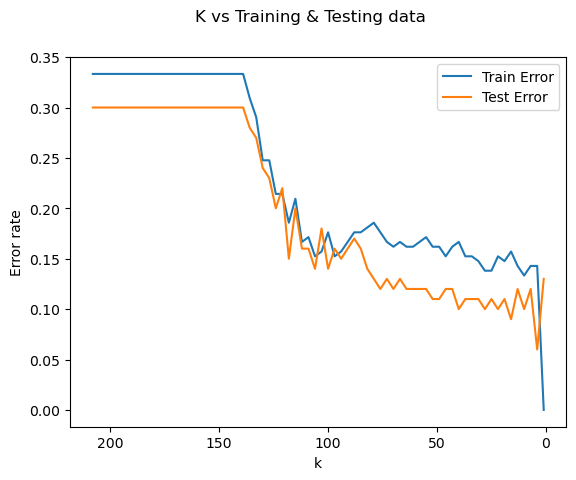

In [20]:
plt.plot(k_values, train_errors, label="Train Error")
plt.plot(k_values, test_errors, label="Test Error")
plt.legend()

plt.xlabel("k")
plt.ylabel("Error rate")
plt.suptitle("K vs Training & Testing data")

plt.gca().invert_xaxis()

identifying best k

In [22]:
best_k = k_values[np.argmin(test_errors)]
print(f"Best k: {best_k}")

Best k: 4


In [23]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_test_pred_best = knn_best.predict(X_test)

Calculate metrics

In [25]:
conf_matrix = confusion_matrix(y_test, y_test_pred_best)
print("Confusion Matrix:\n", conf_matrix)

true_positive_rate = recall_score(y_test, y_test_pred_best) 
print(f"True Positive Rate: {true_positive_rate:.4f}")

true_negative_rate = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
print(f"True Negative Rate: {true_negative_rate:.4f}")

precision = precision_score(y_test, y_test_pred_best)
print(f"Precision: {precision:.4f}")

f1 = f1_score(y_test, y_test_pred_best)
print(f"F1-Score: {f1:.4f}")

Confusion Matrix:
 [[25  5]
 [ 1 69]]
True Positive Rate: 0.9857
True Negative Rate: 0.8333
Precision: 0.9324
F1-Score: 0.9583


iii) Plotting the best test error rate
Learning Curve

Text(0.5, 1.0, 'Learning Curve')

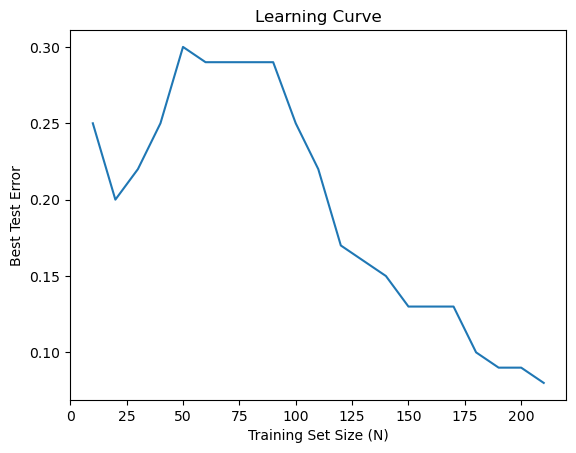

In [27]:
best_test_errors = []
N_values = list(range(10, 211, 10))

for N in N_values:
    n_class0 = class_0.iloc[:N//3]
    n_class1 = class_1.iloc[:N - (N//3)]

    N_train_set = pd.concat([n_class0, n_class1])

    X_N_train = N_train_set.iloc[:, :-1]
    y_N_train = N_train_set['class']

    k_values = list(range(1, 197, 5))
    test_errors = []

    for k in k_values:
        if k<= len(X_N_train):
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_N_train, y_N_train)

            y_test_pred = knn.predict(X_test)

            test_error = 1 - accuracy_score(y_test, y_test_pred)
            test_errors.append(test_error)

    best_test_error = min(test_errors)
    best_test_errors.append(best_test_error)

plt.plot(N_values, best_test_errors)
plt.xlabel('Training Set Size (N)')
plt.ylabel('Best Test Error')
plt.title('Learning Curve')

d) Other metrics

In [ ]:
i) Minkowski Distance

A) Calculating best k using Manhattan Distance with p = 1

In [29]:
k_values = list(range(1, 197, 5))
test_errors_manhattan = []
train_errors_manhattan = []

for k in k_values:
    knn_manhattan = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=1)
    knn_manhattan.fit(X_train, y_train)
    
    y_test_pred = knn_manhattan.predict(X_test)
    y_train_pred = knn_manhattan.predict(X_train)

    test_error = 1 - accuracy_score(y_test, y_test_pred)
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_errors_manhattan.append(test_error)
    train_errors_manhattan.append(train_error)
    
results = pd.DataFrame({'k': k_values, 'Test Error': test_errors_manhattan})
best_test_error_manhattan = min(test_errors_manhattan)
min_error_k_values = results[results['Test Error'] == best_test_error_manhattan]

if len(train_errors_manhattan)>1:
    best_train_error_manhattan = min(train_errors_manhattan[1:])

# best_k_manhattan = k_values[np.argmin(test_errors_manhattan)]
best_k_manhattan = min_error_k_values['k'].max()

print(results)
print(f"Best k for Manhattan distance: {best_k_manhattan}")
print(f"Best Test Error for Manhattan distance: {min(test_errors_manhattan)}")
print(f"Best Training Error for Manhattan distance: {best_train_error_manhattan}")

      k  Test Error
0     1        0.12
1     6        0.11
2    11        0.11
3    16        0.12
4    21        0.12
5    26        0.11
6    31        0.12
7    36        0.13
8    41        0.13
9    46        0.13
10   51        0.14
11   56        0.13
12   61        0.15
13   66        0.15
14   71        0.14
15   76        0.14
16   81        0.16
17   86        0.15
18   91        0.20
19   96        0.20
20  101        0.22
21  106        0.21
22  111        0.23
23  116        0.21
24  121        0.22
25  126        0.24
26  131        0.28
27  136        0.28
28  141        0.30
29  146        0.30
30  151        0.30
31  156        0.30
32  161        0.30
33  166        0.30
34  171        0.30
35  176        0.30
36  181        0.30
37  186        0.30
38  191        0.30
39  196        0.30
Best k for Manhattan distance: 26
Best Test Error for Manhattan distance: 0.10999999999999999
Best Training Error for Manhattan distance: 0.1333333333333333


B) Calculating the best log10(p) when log10(p) belongs to {0.1, 0.2, 0.3,...,1}

In [31]:
log_p_values = np.arange(0.1, 1.1, 0.1)
test_log_errors = []
train_log_errors = []
k = 26

for log_p in log_p_values:
    p = 10**log_p
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=p)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    y_train_pred = knn.predict(X_train)

    test_error = 1 - accuracy_score(y_test, y_pred)
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_log_errors.append(test_error)
    train_log_errors.append(train_error)

best_log_p = log_p_values[np.argmin(test_log_errors)]
print(f"Best log10(p): {best_log_p}")

best_log_train_error = min(train_log_errors)
best_log_test_error = min(test_log_errors)

results = pd.DataFrame({ 'log10(p)': log_p_values, 'Test Error': test_log_errors})
print(results)
print(f"Test error is: {best_log_test_error}")
print(f"Train error is: {best_log_train_error}")

Best log10(p): 0.1
   log10(p)  Test Error
0       0.1        0.10
1       0.2        0.10
2       0.3        0.11
3       0.4        0.10
4       0.5        0.11
5       0.6        0.10
6       0.7        0.11
7       0.8        0.11
8       0.9        0.11
9       1.0        0.11
Test error is: 0.09999999999999998
Train error is: 0.13809523809523805


Chebyshev Distance with p --> infinity

In [32]:
k_values = list(range(1, 197, 5))
test_error_chebyshev = []
train_error_chebyshev = []

for k in k_values:
    knn_chebyshev = KNeighborsClassifier(n_neighbors=k, metric='chebyshev')
    knn_chebyshev.fit(X_train, y_train)
    
    y_test_pred = knn_chebyshev.predict(X_test)
    y_train_pred = knn_chebyshev.predict(X_train)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    train_error = 1 - accuracy_score(y_train, y_train_pred)

    test_error_chebyshev.append(test_error)
    train_error_chebyshev.append(train_error)

# best_k_value = k_values[np.argmin(test_error_chebyshev)]
results = pd.DataFrame({'k': k_values, 'Test Error': test_error_chebyshev})
best_test_error_chebyshev = min(test_error_chebyshev)
min_error_k_values = results[results['Test Error'] == best_test_error_chebyshev]

best_k_chebyshev = min_error_k_values['k'].max()

if len(train_error_chebyshev)>1:
    best_train_error_chebyshev = min(train_error_chebyshev[1:])

print(f"Best value of k is: {best_k_chebyshev}")
print(f"Test error using Chebyshev metric is: {best_test_error_chebyshev}")
print(f"Train error using Chebyshev metric is: {best_train_error_chebyshev}")

Best value of k is: 16
Test error using Chebyshev metric is: 0.07999999999999996
Train error using Chebyshev metric is: 0.1333333333333333


ii) Mahalanobis Distance

In [34]:
cov_matrix = np.cov(X_train, rowvar=False)
inv_cov_matrix = inv(cov_matrix)
mahalanobis_test_errors = []
mahalanobis_train_errors = []

def mahalanobis_distance(x, y, inv_cov_matrix):
    return mahalanobis(x, y, inv_cov_matrix)

for k in k_values:
    knn_mahalanobis = KNeighborsClassifier(n_neighbors=k, metric='mahalanobis', metric_params={'VI': inv_cov_matrix})
    knn_mahalanobis.fit(X_train, y_train)
    
    y_pred = knn_mahalanobis.predict(X_test)
    y_train_pred = knn_mahalanobis.predict(X_train)
    test_error_mahalanobis = 1 - accuracy_score(y_test, y_pred)
    train_error_mahalanobis = 1 - accuracy_score(y_train, y_train_pred)

    mahalanobis_test_errors.append(test_error_mahalanobis)
    mahalanobis_train_errors.append(train_error_mahalanobis)

if len(mahalanobis_train_errors)>1:
    best_mahalanobis_train_error = min(mahalanobis_train_errors[1:])
# best_k_value = k_values[np.argmin(mahalanobis_test_errors)]
results = pd.DataFrame({'k': k_values, 'Test Error': mahalanobis_test_errors})
best_test_error_mahalanobis = min(mahalanobis_test_errors)
min_error_k_values = results[results['Test Error'] == best_test_error_mahalanobis]

best_k_value = min_error_k_values['k'].max()

print(f"Best value of k is: {best_k_value}")
print(f"Test error using Mahalanobis metric is: {best_test_error_mahalanobis}")
print(f"Train error using Mahalanobis metric is: {best_mahalanobis_train_error}")

results = pd.DataFrame({'k': k_values, 'Test Error': mahalanobis_test_errors, 'Training Error': mahalanobis_train_errors})

Best value of k is: 6
Test error using Mahalanobis metric is: 0.17000000000000004
Train error using Mahalanobis metric is: 0.11904761904761907


Summary

In [35]:
summary = pd.DataFrame({ 'Metric': ['Manhattan p=1', 'Minkowski log10(p)', 'Chebyshev', 'Mahalanobis'], 
                        'Test Error': [min(test_errors_manhattan), best_log_test_error, best_test_error_chebyshev, best_test_error_mahalanobis],
                       'Train Error': [best_train_error_manhattan, best_log_train_error, best_train_error_chebyshev, best_mahalanobis_train_error]})
print(summary)

               Metric  Test Error  Train Error
0       Manhattan p=1        0.11     0.133333
1  Minkowski log10(p)        0.10     0.138095
2           Chebyshev        0.08     0.133333
3         Mahalanobis        0.17     0.119048


e) Weighted Decision

In [37]:
k_values = list(range(1, 197, 5))

Euclidean distance Weighted voting

In [39]:
weighted_test_error_euclidean = []
weighted_train_error_euclidean = []

for k in k_values:
    knn_euclidean_weighted = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance')
    knn_euclidean_weighted.fit(X_train, y_train)

    y_train_pred = knn_euclidean_weighted.predict(X_train)
    y_test_pred = knn_euclidean_weighted.predict(X_test)

    test_error = 1 - accuracy_score(y_test, y_test_pred)
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    weighted_train_error_euclidean.append(train_error)
    weighted_test_error_euclidean.append(test_error)

best_weighted_test_error_euclidean = min(weighted_test_error_euclidean)
if len(weighted_train_error_euclidean)>1:
    best_weighted_train_error_euclidean = min(weighted_train_error_euclidean[1:])

# best_k_value = k_values[np.argmin(weighted_test_error_euclidean)]

results = pd.DataFrame({'k': k_values, 'Test Error': weighted_test_error_euclidean})
min_error_k_values = results[results['Test Error'] == best_weighted_test_error_euclidean]

best_k_value = min_error_k_values['k'].max()

print(f"Best value of k is: {best_k_value}")
print(f"The best train error for weighted voting with euclidean distance is: {best_weighted_train_error_euclidean}")
print(f"The best test error for weighted voting with euclidean distance is: {best_weighted_test_error_euclidean}")


results = pd.DataFrame({'k': k_values, 'Test Error': weighted_test_error_euclidean, 'Training Error': weighted_train_error_euclidean})
# print(results)

Best value of k is: 6
The best train error for weighted voting with euclidean distance is: 0.0
The best test error for weighted voting with euclidean distance is: 0.09999999999999998


Manhattan distance Weighted voting

In [41]:
weighted_test_error_manhattan = []
weighted_train_error_manhattan = []

for k in k_values:
    knn_manhattan_weighted = KNeighborsClassifier(n_neighbors=k, metric='manhattan', weights='distance')
    knn_manhattan_weighted.fit(X_train, y_train)

    y_test_pred = knn_manhattan_weighted.predict(X_test)
    y_train_pred = knn_manhattan_weighted.predict(X_train)

    test_error = 1 - accuracy_score(y_test, y_test_pred)
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    weighted_test_error_manhattan.append(test_error)
    weighted_train_error_manhattan.append(train_error)


if len(weighted_train_error_manhattan)>1:
    best_weighted_train_error_manhattan = min(weighted_train_error_manhattan[1:])

# best_k_value = k_values[np.argmin(weighted_test_error_manhattan)]

results = pd.DataFrame({'k': k_values, 'Test Error': weighted_test_error_manhattan})
best_weighted_test_error_manhattan = min(weighted_test_error_manhattan)
min_error_k_values = results[results['Test Error'] == best_weighted_test_error_manhattan]

best_k_value = min_error_k_values['k'].max()

print(f"Best value of k is: {best_k_value}")
print(f"The best test error of weighted voting with manhattan distance is: {best_weighted_test_error_manhattan}")
print(f"The best train error of weighted voting with manhattan distance is: {best_weighted_train_error_manhattan}")

results = pd.DataFrame({'k': k_values, 'Test Error': best_test_error, 'Training Error': best_weighted_train_error_manhattan})
print(results)

Best value of k is: 26
The best test error of weighted voting with manhattan distance is: 0.09999999999999998
The best train error of weighted voting with manhattan distance is: 0.0
      k  Test Error  Training Error
0     1        0.08             0.0
1     6        0.08             0.0
2    11        0.08             0.0
3    16        0.08             0.0
4    21        0.08             0.0
5    26        0.08             0.0
6    31        0.08             0.0
7    36        0.08             0.0
8    41        0.08             0.0
9    46        0.08             0.0
10   51        0.08             0.0
11   56        0.08             0.0
12   61        0.08             0.0
13   66        0.08             0.0
14   71        0.08             0.0
15   76        0.08             0.0
16   81        0.08             0.0
17   86        0.08             0.0
18   91        0.08             0.0
19   96        0.08             0.0
20  101        0.08             0.0
21  106        0.08       

Chebyshev distance Weighted voting

In [43]:
weighted_train_error_chebyshev = []
weighted_test_error_chebyshev = []

for k in k_values:
    knn_chebyshev_weighted = KNeighborsClassifier(n_neighbors=k, metric='chebyshev', weights='distance')
    knn_chebyshev_weighted.fit(X_train, y_train)

    y_train_pred = knn_chebyshev_weighted.predict(X_train)
    y_test_pred = knn_chebyshev_weighted.predict(X_test)

    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    weighted_train_error_chebyshev.append(train_error)
    weighted_test_error_chebyshev.append(test_error)


if len(weighted_train_error_euclidean)>1:
    best_weighted_train_error_chebyshev = min(weighted_train_error_chebyshev[1:])

# best_k_value = k_values[np.argmin(weighted_test_error_chebyshev)]
results = pd.DataFrame({'k': k_values, 'Test Error': weighted_test_error_chebyshev})
best_test_error_chebyshev = min(weighted_test_error_chebyshev)
min_error_k_values = results[results['Test Error'] == best_test_error_chebyshev]

best_k_value = min_error_k_values['k'].max()

print(f"Best value of k is: {best_k_value}")
print(f"The best train error of weighted voting with chebyshev distance is: {best_weighted_train_error_chebyshev}")
print(f"The best test error of weighted voting with chebyshev distance is: {best_test_error_chebyshev}")

Best value of k is: 61
The best train error of weighted voting with chebyshev distance is: 0.0
The best test error of weighted voting with chebyshev distance is: 0.10999999999999999


f) Training Error Rate

In [45]:
lowest_training_error = min(best_train_error,
                   best_train_error_manhattan,
                   best_log_train_error,
                   best_train_error_chebyshev,
                   best_mahalanobis_train_error,
                   best_weighted_train_error_euclidean, 
                   best_weighted_train_error_manhattan, 
                   best_weighted_train_error_chebyshev)
print(f"The lowest training error I got in this homework is: {lowest_training_error}")

results = pd.DataFrame({'Question': ['c.ii) Euclidian', 'd.i.A) Manhattan', 'd.i.B) Minkowski', 'd.i.C) Chebyshev', 'd.ii) Mahalanobis', 'e) Euclidean', 'e) Manhattan', 'e) Chebyshev'], 
                        'Training Error':[best_train_error,best_train_error_manhattan, best_log_train_error, best_train_error_chebyshev, best_mahalanobis_train_error, best_weighted_train_error_euclidean, best_weighted_train_error_manhattan, best_weighted_train_error_chebyshev] })
print(results)

The lowest training error I got in this homework is: 0.0
            Question  Training Error
0    c.ii) Euclidian        0.333333
1   d.i.A) Manhattan        0.133333
2   d.i.B) Minkowski        0.138095
3   d.i.C) Chebyshev        0.133333
4  d.ii) Mahalanobis        0.119048
5       e) Euclidean        0.000000
6       e) Manhattan        0.000000
7       e) Chebyshev        0.000000


--------------------------------------------------------------CITATIONS & REFERENCES-----------------------------------------------------------------

##### handling white space
Took reference from chatgpt to ask why most of my columns show Nan values

prompt: when i load my dataset in jupyter notebook it shows Nan in most of the columns, and inserts all the data into one single column despite having values for each column. i think the whitespaces are not being handled correctly. How can this issue be solved?

response: It sounds like the dataset is not being properly parsed due to whitespaces, which may cause the values to be read into a single column or result in NaN values.To address this issue, you can try the following steps: Check the delimiter: The dataset may not be separated by commas but by other characters (such as tabs, spaces, or semicolons). You can specify the delimiter when loading the data using the sep argument in pandas.read_cv()  ####) 



#box plot
Took reference from chatgpt

prompt: how can we plot different box plots for each variable of the dataset? I need to plot multiple box plots in a single figure, what should i use?

Response: plt.subplots(nrows=1, ncols=num_cols): Creates a grid of subplots with one row and a number of columns equal to the number of variables in the dataset. The loop iterates over each column in the dataset, creating a box plot for each variable in its own subplot. tight_layout() is used to ensure that the subplots do’3.  ##t##  overlap.



#selecting indices
Took reference from chatgpt

prompt: in my dataset, suppose i want to only select data through selected indices how can i do that?

response: To select data from a dataset using specific indices in Python (assuming you are using pandas), you can use the .iloc[] or .loc[] functions depending on whether you want to select by positional indices or y 4.  ##l## abel-based indices



#KNN implementation
took reference from chatgpt to know if there are any libraries to implement knn

prompt: is there any library that i can use for applying knn algorithm in jupyter notebook?

response: Yes, you can use the scikit-learn library, which is one of the most popular libraries in Python for machine learning, to apply the K-nearest neighbors (KNN) algorithm in Jupyter Notebook. It provides a simple and efficient way to implement KNN. Based on the sample code it had provided, i searched for KNeighborsClassifier implementation on google and learnt about it from scki5.  ##t## -learn-1.5.2 documentation.



#invert axis
asked chatgpt how to reverse axis in my graph 
response: To reverse an axis in a graph in matplotlib, you can use the following functions: Reverse the x-axis: Use plt.gca().invert_xaxis() Reverse the -6.  ##a## xis: Use plt.gca().invert_yaxis()



#minkowski
Used the same reference document scikit-learn-1.5.2 for learning about how to use different metrics and p values link to the doc: https://scikit-learn.org/stable/modules/generated/ske7.. ##a## rn.neighbors.KNeighborsClassifier.html



#mahalanobis
Took reference from chatgpt about the mahalanobis metric

prompt: what is the mahalanobis metric? The Mahalanobis distance is a distance metric that measures the distance between a point and a distribution, rather than between two points directly. Unlike the more common Euclidean distance, which calculates straight-line distance, Mahalanobis distance takes into account the correlations and the distribution of the data, making it useful for identifying outliers and comparing points in high-dimensional spaces. gave me a sample code that helped me in creating covariance mt8.  ####r ix and inverse, and the use of metric_params.



#weighted voting
Refered to the same documentation https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborser.html to understand the implementation of weights



